In [ ]:
# importera bibliotek för datahantering, SQL-frågor och visualisering
import pandas as pd 
import numpy as np
import duckdb 
import matplotlib.pyplot as plt

In [31]:
# läser in de fyra csv-filerna som skapats i ETL-pipeline mappen
df_bostader  = pd.read_csv('ETL_Pipline/bostader.csv')
df_priser    = pd.read_csv('ETL_Pipline/priser.csv')
df_platser   = pd.read_csv('ETL_Pipline/platser.csv')
df_visningar = pd.read_csv('ETL_Pipline/visningar.csv')

In [32]:
# separera köp och hyra
kop = df[df['upplåtelseform'] == 'köpa'].copy()
hyra = df[df['upplåtelseform'] == 'hyra'].copy()

# hyra per kvm för hyresrätter
hyra['hyra_per_kvm'] = hyra['pris'] / hyra['boyta']

print(f"Köpobjekt: {len(kop)}")
print(f"Hyresobjekt: {len(hyra)}")

Köpobjekt: 781
Hyresobjekt: 219


In [ ]:
# dyraste huset i varje stad (bara köp)
dyrast_per_stad = kop.loc[kop.groupby('stad')['pris'].idxmax()]

print("dyraste huset i varje stad:")
display(dyrast_per_stad[['stad', 'adress', 'typ', 'boyta', 'pris', 'pris_per_kvm', 'område']])

dyraste huset i varje stad:


,stad,adress,typ,boyta,pris,pris_per_kvm,område
323,Göteborg,Sveavägen 34,hus,162,12459585,76911.0,Linnéstaden
622,Malmö,Kyrkogatan 80,hus,168,8769010,52196.0,Hyllie
47,Stockholm,Parkvägen 24,lägenhet,162,21282713,131375.0,Lidingö


In [ ]:
# separera hyresrätter (lägenheter)
hyra = df[df['upplåtelseform'] == 'hyra'].copy()
hyra_lagenhet = hyra[hyra['typ'] == 'lägenhet'].copy()

# beräkna hyra per kvm
hyra_lagenhet['hyra_per_kvm'] = hyra_lagenhet['pris'] / hyra_lagenhet['boyta']

# dyraste hyreslägenheten i varje stad
dyrast_hyra_per_stad = hyra_lagenhet.loc[hyra_lagenhet.groupby('stad')['pris'].idxmax()]

print("dyraste hyreslägenheten i varje stad:")
display(dyrast_hyra_per_stad[['stad', 'adress', 'typ', 'rum', 'boyta', 'pris', 'hyra_per_kvm', 'område']])

dyraste hyreslägenheten i varje stad:


,stad,adress,typ,rum,boyta,pris,hyra_per_kvm,område
718,Göteborg,Drottninggatan 45,lägenhet,6,162,28140,173.703704,Linnéstaden
17,Malmö,Bergsgatan 42,lägenhet,6,144,24526,170.319444,Hyllie
499,Stockholm,Björkgatan 25,lägenhet,6,168,23816,141.761905,Bromma


In [ ]:
# antal hus vs lägenhet per stad
typ_per_stad = pd.crosstab(df['stad'], df['typ'])
print("Hus vs Lägenheter per stad")
display(typ_per_stad)

Hus vs Lägenheter per stad


typ,hus,lägenhet
stad,,
Göteborg,155,174
Malmö,184,155
Stockholm,164,168


In [ ]:
import duckdb

con = duckdb.connect()
con.register('kop', kop)

# alla viktiga queries på en gång
print("snitt pris per kvm per stad:")
display(con.execute("SELECT stad, ROUND(AVG(pris_per_kvm),0) as snitt_pris_per_kvm, COUNT(*) FROM kop GROUP BY stad ORDER BY snitt_pris_per_kvm DESC").fetchdf())

print("hus vs lägenhet")
display(con.execute("SELECT typ, ROUND(AVG(pris_per_kvm),0) as snitt, COUNT(*) FROM kop GROUP BY typ").fetchdf())

print("snitt pris per kvm per område")
display(con.execute("SELECT område, ROUND(AVG(pris_per_kvm),0) as snitt, COUNT(*) FROM kop GROUP BY område HAVING COUNT(*) >= 3 ORDER BY snitt DESC LIMIT 5").fetchdf())

snitt pris per kvm per stad:


,stad,snitt_pris_per_kvm,count_star()
0,Stockholm,104847.0,256
1,Göteborg,60914.0,253
2,Malmö,42070.0,272


hus vs lägenhet


,typ,snitt,count_star()
0,hus,68726.0,474
1,lägenhet,68791.0,307


snitt pris per kvm per område


,område,snitt,count_star()
0,Södermalm,109520.0,30
1,Solna,109498.0,16
2,Vasastan,108614.0,30
3,Hägersten,107448.0,14
4,Östermalm,106534.0,15


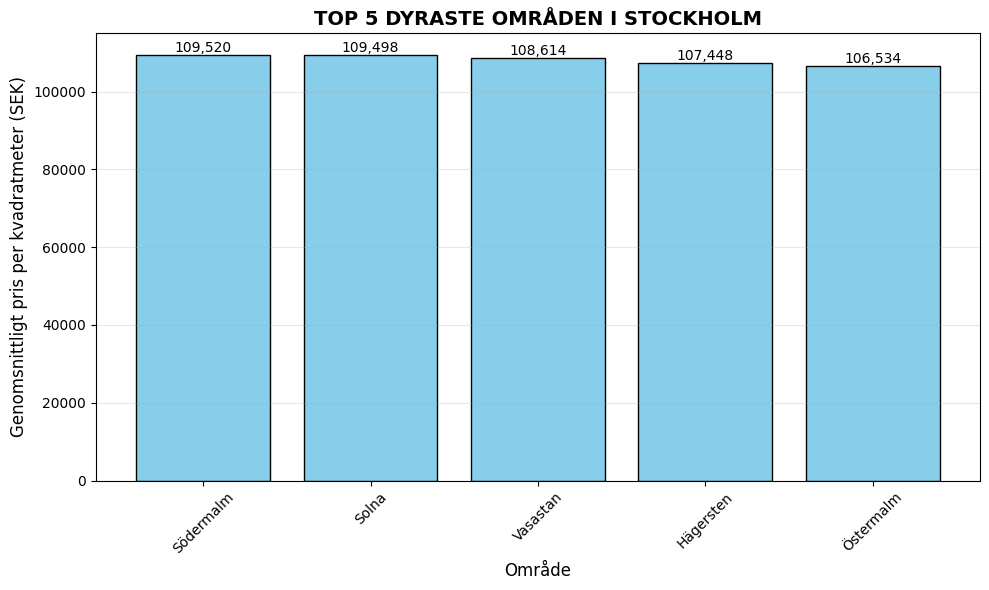

In [ ]:
import matplotlib.pyplot as plt

# din data från duckdb
top_omraden = con.execute("SELECT område, ROUND(AVG(pris_per_kvm),0) as snitt FROM kop GROUP BY område HAVING COUNT(*) >= 3 ORDER BY snitt DESC LIMIT 5").fetchdf()

# skapa bar chart
plt.figure(figsize=(10,6))
bars = plt.bar(top_omraden['område'], top_omraden['snitt'], color='skyblue', edgecolor='black')

# lägg till värden på staplarna
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height):,}', ha='center', va='bottom')

plt.title('TOP 5 DYRASTE OMRÅDEN I STOCKHOLM', fontsize=14, fontweight='bold')
plt.xlabel('Område', fontsize=12)
plt.ylabel('Genomsnittligt pris per kvadratmeter (SEK)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

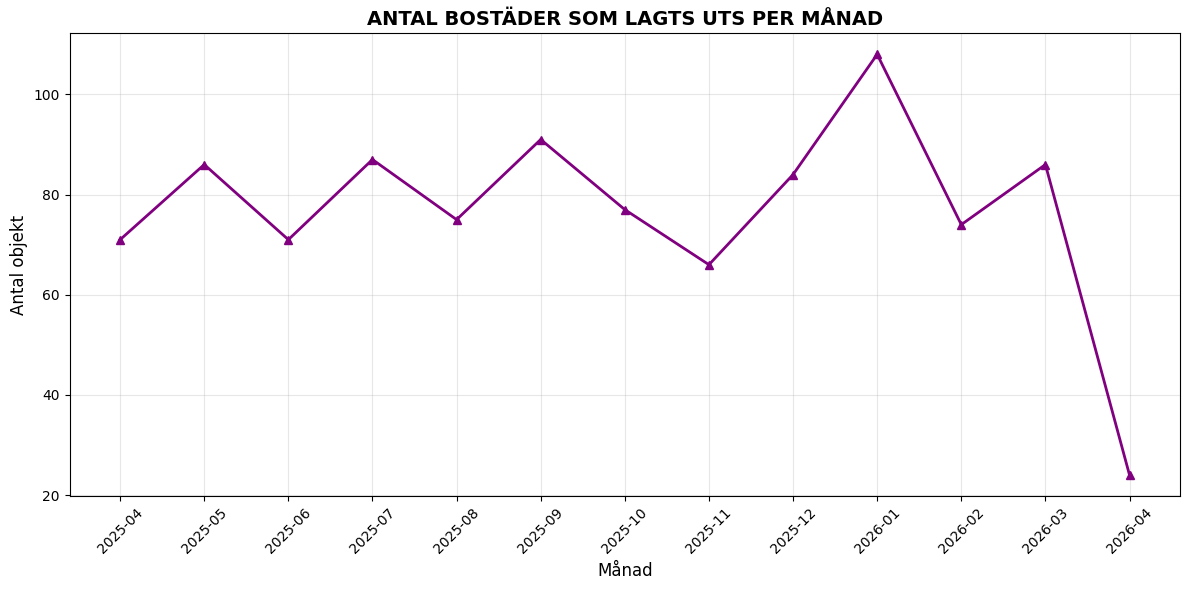

In [33]:
# line chart över hur många objekt som lagts ut per månad
antal_over_tid = df.groupby(pd.to_datetime(df['created_at']).dt.to_period('M')).size().reset_index(name='antal')
antal_over_tid['created_at'] = antal_over_tid['created_at'].astype(str)

plt.figure(figsize=(12,6))
plt.plot(antal_over_tid['created_at'], antal_over_tid['antal'], marker='^', linewidth=2, markersize=6, color='purple')

plt.title('ANTAL BOSTÄDER SOM LAGTS UTS PER MÅNAD', fontsize=14, fontweight='bold')
plt.xlabel('Månad', fontsize=12)
plt.ylabel('Antal objekt', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()